# Lesson 4.3 — The Yoshikawa Manipulability Measure
**Module 6 · Unit 4 · Lesson 15**

Metric second: $w=\sqrt{\det(JJ^\top)}=\prod_i\sigma_i$ (ellipsoid volume). For the planar 2R, $w=|L_1L_2\sin\theta_2|$ (the M5 expression). We confirm the identities, plot $w(\theta_2)$, and expose the isotropy blind spot. (We evaluate $w$ as the product of singular values — equal to $\sqrt{\det(JJ^\top)}$ but numerically robust at the singular pose.)

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]
def manip(J):
    # w = sqrt(det(J Jt)) = product of singular values (numerically robust, always >= 0)
    return float(np.prod(np.linalg.svd(J, compute_uv=False)))


## w = sqrt(det(J Jᵀ)) = product of singular values = |det J| (square)

In [2]:
checks=[]
P2=[(0,0,1,0),(0,0,1,0)]; T2=["R","R"]
Jv=Jv_planar(P2,T2,np.array([0.5,0.8]))
w=np.sqrt(np.linalg.det(Jv@Jv.T)); S=np.linalg.svd(Jv,compute_uv=False)
print("sqrt(det(J Jt)) =",round(w,4)," prod(sigma) =",round(np.prod(S),4)," |det J| =",round(abs(np.linalg.det(Jv)),4))
checks.append(np.isclose(w,np.prod(S),atol=1e-9) and np.isclose(w,abs(np.linalg.det(Jv)),atol=1e-9))

sqrt(det(J Jt)) = 0.7174  prod(sigma) = 0.7174  |det J| = 0.7174


## w(θ₂) = |L₁L₂ sin θ₂|: max at 90°, zero (singular) when straight

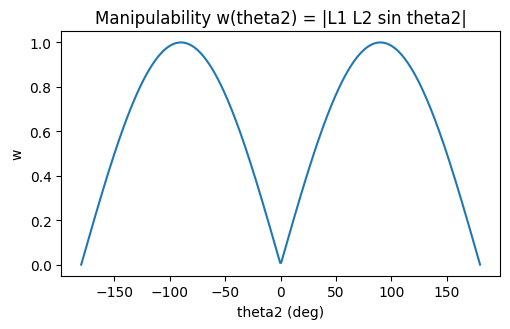

max w = 1.0  (expect ~1 at +/-90 deg)
w at straight pose (theta2=0) = 0.0


In [3]:
import matplotlib.pyplot as plt
th2=np.linspace(-np.pi,np.pi,400)
wv=[manip(Jv_planar(P2,T2,np.array([0.3,t]))) for t in th2]   # product of singular values (>=0)
plt.figure(figsize=(5.2,3.4)); plt.plot(np.degrees(th2),wv)
plt.xlabel('theta2 (deg)'); plt.ylabel('w'); plt.title('Manipulability w(theta2) = |L1 L2 sin theta2|'); plt.tight_layout(); plt.show()
print("max w =",round(max(wv),4)," (expect ~1 at +/-90 deg)")
print("w at straight pose (theta2=0) =",round(manip(Jv_planar(P2,T2,np.array([0.3,0.0]))),9))
checks.append(np.isclose(max(wv),1.0,atol=1e-2))
checks.append(manip(Jv_planar(P2,T2,np.array([0.3,0.0])))<1e-9)

## The isotropy blind spot: equal w, different shapes

In [4]:
def stats(q):
    J=Jv_planar(P2,T2,q); s=np.linalg.svd(J,compute_uv=False)
    return float(np.prod(s)), float(s[0]/s[1])
# same |sin theta2| -> same w, but extended vs folded -> different SHAPE (condition number)
qa=np.array([0.3,0.6]); qb=np.array([0.3,np.pi-0.6])
wa,ka=stats(qa); wb,kb=stats(qb)
print(f"theta2={qa[1]:.3f} (extended): w={wa:.3f}  condition={ka:.2f}")
print(f"theta2={qb[1]:.3f} (folded)  : w={wb:.3f}  condition={kb:.2f}")
print("-> EQUAL w (same |sin theta2|), DIFFERENT shape: w cannot tell them apart;")
print("   the condition number (L6.3) separates the elongated ellipse from the round one")
checks.append(np.isclose(wa,wb,atol=1e-6) and abs(ka-kb)>1.0)
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

theta2=0.600 (extended): w=0.565  condition=8.11
theta2=2.542 (folded)  : w=0.565  condition=1.85
-> EQUAL w (same |sin theta2|), DIFFERENT shape: w cannot tell them apart;
   the condition number (L6.3) separates the elongated ellipse from the round one
All checks passed.
